# FINE vs ETAS across forecast horizons

Same catalog, same FINE checkpoint, different forecast lengths. The Hauksson pre-Ridgecrest short walk is the example: `horizon_0.5d` and `horizon_1d` under `outputs/rolling_continuation_hauksson_pre_ridgecrest_short`.

The next cell runs `runnable_code/cache_horizon_comparison.py`. That script fills each horizon's analysis cache — the scores, window tests, intensity grids, and catalogs used by `compare_rolling_etas_fine_horizon_bayona.ipynb` — and writes comparison tables next to the horizons:

```text
outputs/rolling_continuation_hauksson_pre_ridgecrest_short/horizon_comparison/
    scores.csv          one row per horizon, window, and method
    window_tests.csv    negative-binomial and binary likelihood tests
    summary.csv         means and consistency fractions
    manifest.json       pointers back to each horizon's analysis cache
```

A repeat run does not rebuild a horizon whose forecast files are unchanged. A new realization is computed inside that horizon's analysis cache, and only that horizon's comparison rows are replaced. Window tests for a horizon are recomputed when its seed list changes, because they use the seed-averaged intensity. Pass `--force` only to rebuild the comparison tables and window tests; intensity grids are still reused when the forecast files are unchanged.

The short walk (0.5 d and 1 d) is read from cache. The 7 d, 60 d, and 300 d walk is a separate output folder. `N_REALIZATIONS` is the most catalogs to cache per method in each window there: the lowest seed ids, or every catalog when fewer exist. A horizon that already contains those realizations is not rebuilt.

Other notebooks load the same tables without recomputing:

```python
import etas.horizon_comparison as horizon_comparison
comparison = horizon_comparison.load_comparison(output_root)
comparison.summary
comparison.scores
comparison.analysis(1.0)   # grids and catalogs for one horizon
```


In [1]:
%matplotlib inline
from __future__ import annotations

import subprocess
import sys
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

import etas.horizon_comparison as horizon_comparison
import etas.rolling_analysis as rolling_analysis

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "cache_horizon_comparison.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "cache_horizon_comparison.py").is_file():
                REPO_ROOT = parent
                break

# N_REALIZATIONS caps catalogs cached per method in each window (lowest seed ids).
# A window with fewer catalogs uses all of them. Horizons that already contain
# those realizations are left as cached.
N_REALIZATIONS = 3
EXPERIMENTS = [
    {
        "output_root": REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest_short",
        "config": REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest_short.json",
        "horizon_days": [0.5, 1.0],
        "from_cache": True,
        "n_realizations": None,
    },
    {
        "output_root": REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest",
        "config": REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest.json",
        "horizon_days": [7.0, 60.0, 300.0],
        "from_cache": False,
        "n_realizations": N_REALIZATIONS,
    },
]
METHODS = ["etas", "FINE"]
CSEP_DH = 0.1
BAYONA_N_SIM = 200
METHOD_COLORS = {"etas": "seagreen", "FINE": "mediumpurple"}
METHOD_LABELS = {"etas": "ETAS", "FINE": "FINE"}


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


def _span(low: float, high: float) -> str:
    low_i, high_i = int(low), int(high)
    if low_i == high_i:
        return str(low_i)
    return f"{low_i}–{high_i}"


def _model_text(payload: dict) -> str:
    model_dir = Path(str((payload.get("magnet") or {}).get("model_dir") or ""))
    parts = model_dir.parts
    variant = ""
    if "FINE_variants" in parts:
        index = parts.index("FINE_variants") + 1
        if index < len(parts):
            variant = parts[index]
    model_part = next((part for part in parts if part.startswith("model_")), "")
    model_id = model_part.removeprefix("model_")[:12] or model_dir.name
    repetition = next((part for part in parts if part.startswith("_repetition_")), "")
    repetition_n = repetition.removeprefix("_repetition_") if repetition else "0"
    variant_text = f"{variant}, " if variant else ""
    return f"FINE-MAGNET {model_id} ({variant_text}repetition {repetition_n}) and ETAS"


def _dataset_text(payload: dict) -> str:
    catalog = Path(str(payload.get("fn_catalog") or "")).name
    region = str(payload.get("region") or "")
    name = "Hauksson" if "hauksson" in catalog.lower() else catalog
    mc = payload.get("mc")
    mc_text = f", Mc {float(mc):g}" if isinstance(mc, (int, float)) else ""
    region_text = f", {region.capitalize()}" if region else ""
    start = str(payload.get("timewindow_end") or "")[:10]
    end = str(payload.get("testwindow_end") or "")[:10]
    span = f", forecasts {start} to {end}" if start and end else ""
    return f"{name}{region_text} ({catalog}){mc_text}{span}"


def _unique_config_text(reader) -> str:
    labels: list[str] = []
    for experiment in EXPERIMENTS:
        payload = json.loads(Path(experiment["config"]).read_text(encoding="utf-8"))
        label = reader(payload)
        if label not in labels:
            labels.append(label)
    return "; ".join(labels)


def _disk_realization_span(output_root: Path, horizon_days: float, method: str) -> str:
    horizon_dir = rolling_analysis.horizon_directory(output_root, horizon_days)
    counts = [
        len(rolling_analysis._forecast_files(step_dir, method))
        for _index, step_dir in rolling_analysis._discover_steps(horizon_dir)
    ]
    if not counts:
        return "0"
    return _span(min(counts), max(counts))


def _loaded_realization_span(scores: pd.DataFrame, horizon_days: float, method: str) -> str:
    if scores.empty or "n_seeds" not in scores.columns:
        return "0"
    mask = np.isclose(scores["horizon_days"].to_numpy(dtype=float), float(horizon_days))
    values = pd.to_numeric(
        scores.loc[mask & (scores["method"] == method), "n_seeds"],
        errors="coerce",
    ).dropna()
    if values.empty:
        return "0"
    return _span(float(values.min()), float(values.max()))


script = REPO_ROOT / "runnable_code" / "cache_horizon_comparison.py"
summaries = []
score_frames = []
for experiment in EXPERIMENTS:
    command = [
        sys.executable,
        str(script),
        "--output-root", str(experiment["output_root"]),
        "--config", str(experiment["config"]),
        "--repo-root", str(REPO_ROOT),
        "--horizon-days", *[str(days) for days in experiment["horizon_days"]],
        "--dh", str(CSEP_DH),
        "--num-simulations", str(BAYONA_N_SIM),
        "--methods", *METHODS,
    ]
    if experiment["from_cache"]:
        command.append("--from-cache")
    if experiment["n_realizations"] is not None:
        command.extend(["--n-realizations", str(experiment["n_realizations"])])
    process = subprocess.Popen(
        command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="", flush=True)
    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(f"comparison cache script exited {return_code}")
    loaded = horizon_comparison.load_comparison(experiment["output_root"])
    summaries.append(loaded.summary)
    score_frames.append(loaded.scores.assign(_output_root=str(experiment["output_root"])))

summary = pd.concat(summaries, ignore_index=True)
summary = summary.sort_values(["horizon_days", "method"]).reset_index(drop=True)
scores = pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()
coverage = summary.drop_duplicates("horizon_days")[
    ["horizon_days", "n_steps_cached", "n_steps_on_disk", "n_seeds"]
]

rows = []
for days in coverage["horizon_days"]:
    days = float(days)
    experiment = next(
        item for item in EXPERIMENTS
        if any(np.isclose(days, float(value)) for value in item["horizon_days"])
    )
    window_rows = summary.loc[np.isclose(summary["horizon_days"], days)]
    rows.append({
        "Horizon": f"{days:g} d",
        "Windows loaded": int(window_rows["n_steps_cached"].iloc[0]),
        "Windows total": int(window_rows["n_steps_on_disk"].iloc[0]),
        "ETAS loaded": _loaded_realization_span(scores, days, "etas"),
        "ETAS on disk": _disk_realization_span(experiment["output_root"], days, "etas"),
        "FINE loaded": _loaded_realization_span(scores, days, "FINE"),
        "FINE on disk": _disk_realization_span(experiment["output_root"], days, "FINE"),
    })
loaded_table = pd.DataFrame(rows)
loaded_table.columns = pd.MultiIndex.from_tuples([
    ("", "Horizon"),
    ("Windows", "Loaded"),
    ("Windows", "Total"),
    ("ETAS realizations", "Loaded"),
    ("ETAS realizations", "On disk"),
    ("FINE realizations", "Loaded"),
    ("FINE realizations", "On disk"),
])
varies = loaded_table.astype(str).apply(lambda column: column.str.contains("–")).any().any()
note = (
    " A range is the smallest and largest count across windows."
    " Loaded realizations are the catalogs in the cached scores;"
    " on disk is every forecast catalog for that horizon."
    if varies else ""
)
display(Markdown(
    f"**Model:** {_unique_config_text(_model_text)}\n\n"
    f"**Dataset:** {_unique_config_text(_dataset_text)}\n\n"
    f"Realizations in the loaded scores, and how many exist on disk.{note}"
))
display(HTML(loaded_table.to_html(index=False)))


horizon_0.5d: using cache, 2267 of 2267 windows
horizon_0.5d: comparison tables current
horizon_1d: using cache, 1134 of 1134 windows
horizon_1d: comparison tables current
comparison up to date: 2 horizons
comparison cache: /home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest_short/horizon_comparison (2 horizons, 0 refreshed)
horizon_7d: cache up to date: 162 steps, 30 seeds
horizon_7d: window tests cached: 162 steps, 2 methods, 200 binary likelihood simulations
horizon_7d: comparison tables current
horizon_60d: cache up to date: 19 steps, 30 seeds
horizon_60d: window tests cached: 19 steps, 2 methods, 200 binary likelihood simulations
horizon_60d: comparison tables current
horizon_300d: cache up to date: 4 steps, 30 seeds
horizon_300d: window tests cached: 4 steps, 2 methods, 200 binary likelihood simulations
horizon_300d: comparison tables current
comparison up to date: 3 horizons
comparison cache: /home/neriberman/Repos/etas/outputs/rolling_continuation_h

**Model:** FINE-MAGNET 9e2618ba2630 (mc_depth, repetition 0) and ETAS

**Dataset:** Hauksson, California (etas_converted_hauksson.csv), Mc 2.4, forecasts 2016-05-23 to 2019-07-01

Realizations in the loaded scores, and how many exist on disk. A range is the smallest and largest count across windows. Loaded realizations are the catalogs in the cached scores; on disk is every forecast catalog for that horizon.

## Metrics vs forecast horizon

One line per method for each scalar that the Bayona single-horizon notebook summarizes. Values come from the comparison cache (`summary.csv` and per-window `scores.csv`). The cumulative number test is the Bayona Fig. 3c comparison across horizons: black points are expected totals, colored points are the observed total (coolwarm by percentage discrepancy), solid bars are Poisson 95% intervals, and dashed bars are negative-binomial 95% intervals. Consistency fractions use the 95% thresholds from that notebook. ζ calibration area is the integrated gap between the sorted window quantiles and Uniform(0, 1).

FINE-against-ETAS scalars (one line, not one per method) are in the next section.


,horizon_days,method,n_forecast,n_observed,delta_percent,poisson_low,poisson_high,nbd_low,nbd_high,catalog_variance
0,0.5,FINE,1016.274209,1088.0,6.592444,954.0,1079.0,22.0,3828.0,1.084432e+06
1,0.5,etas,2194.064765,1088.0,50.411673,2103.0,2286.0,2100.0,2289.0,2.341333e+03
2,1.0,FINE,3541.141915,1088.0,69.275448,3425.0,3658.0,74.0,13382.0,1.326125e+07
3,1.0,etas,825.343113,1088.0,24.141258,770.0,882.0,761.0,891.0,1.104500e+03
4,7.0,FINE,974.806271,1088.0,10.403835,914.0,1036.0,74.0,3002.0,6.150068e+05
5,7.0,etas,909.672914,1088.0,16.390357,851.0,969.0,417.0,1589.0,9.099334e+04
6,60.0,FINE,1151.422408,1088.0,5.508179,1085.0,1218.0,63.0,3772.0,1.000175e+06
7,60.0,etas,929.083122,1088.0,14.606331,870.0,989.0,666.0,1234.0,2.105851e+04
8,300.0,FINE,1072.704722,1088.0,1.405816,1009.0,1137.0,186.0,2719.0,4.444291e+05
9,300.0,etas,1067.194505,1088.0,1.912270,1004.0,1132.0,815.0,1352.0,1.884077e+04


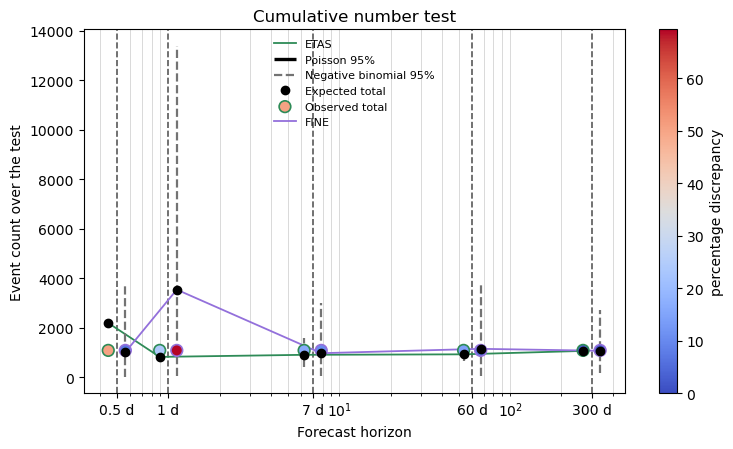

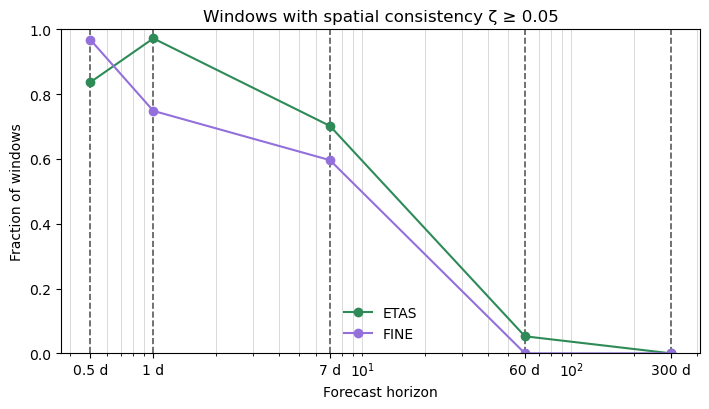

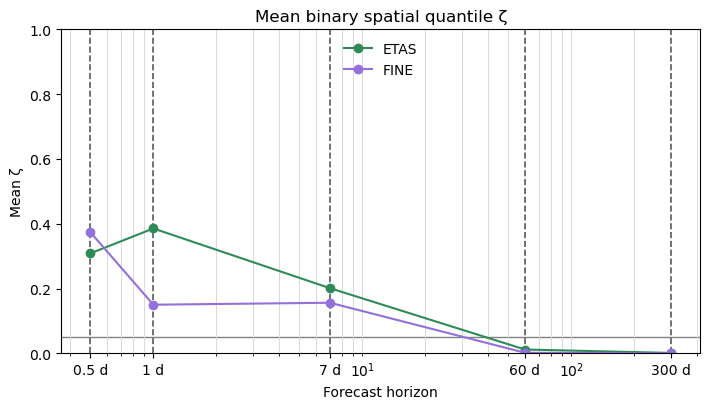

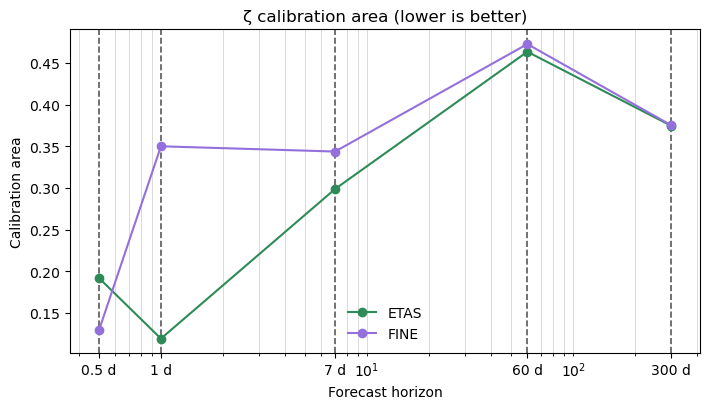

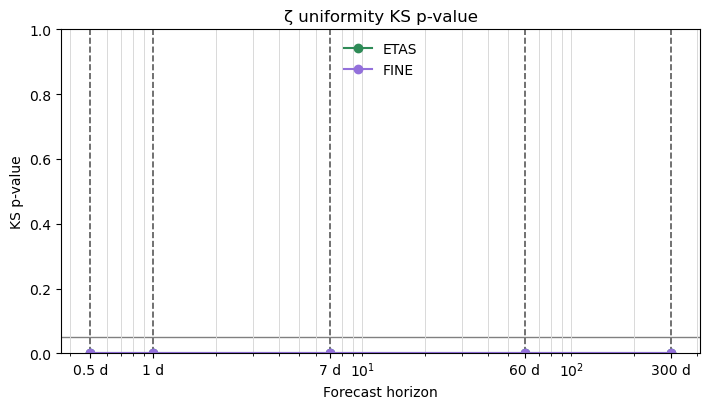

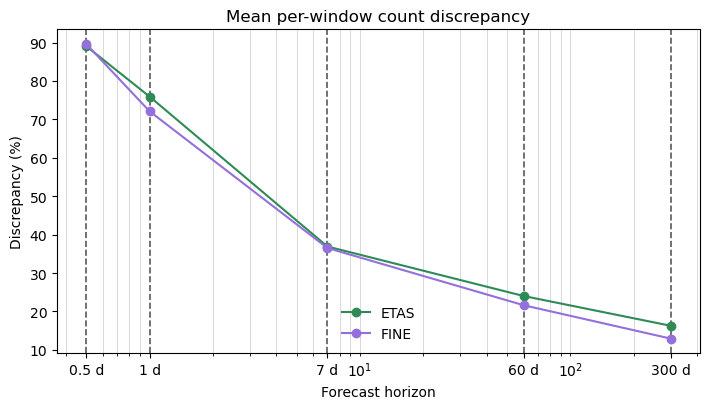

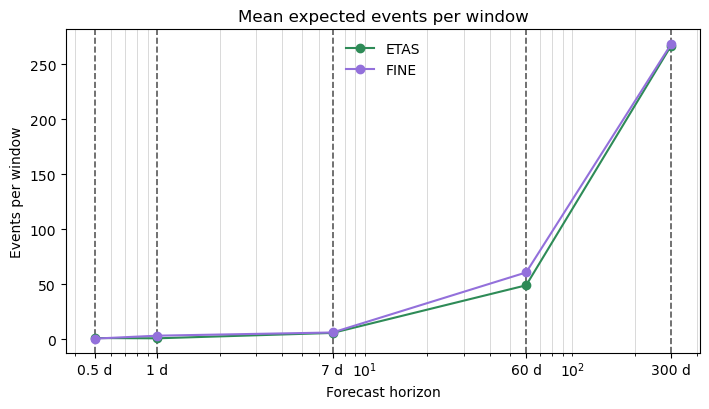

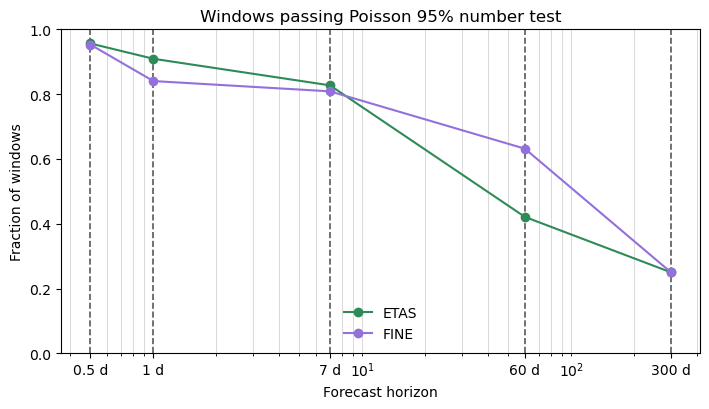

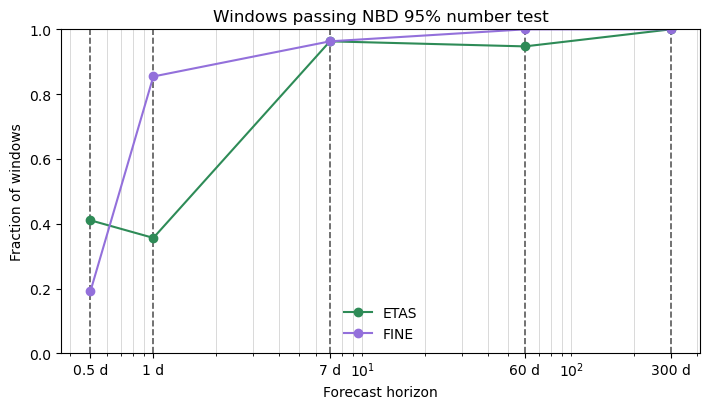

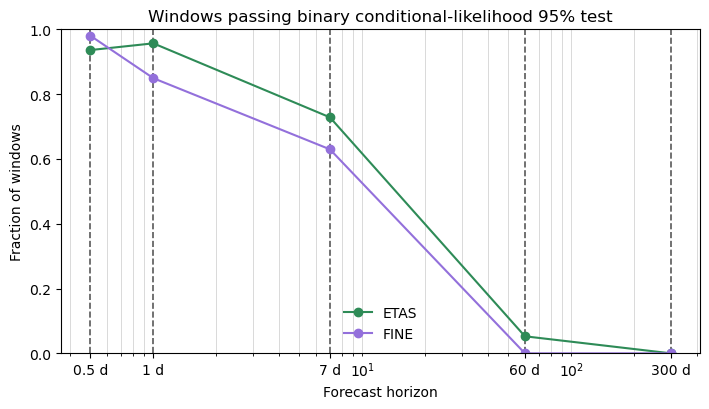

In [2]:
from matplotlib.ticker import FixedFormatter, FixedLocator, LogLocator

import etas.bayona_evaluations as bayona_evaluations

horizons = [float(days) for days in coverage["horizon_days"]]
methods = [method for method in METHODS if method in set(summary["method"])]
partial = bool((coverage["n_steps_cached"] < coverage["n_steps_on_disk"]).any())
partial_note = " (cached windows)" if partial else ""
_LOG_OFFSET = {"etas": -0.05, "FINE": 0.05}


def _style_horizon_axis(ax) -> None:
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(horizons))
    ax.xaxis.set_major_formatter(FixedFormatter([f"{days:g} d" for days in horizons]))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10)))
    ax.grid(True, which="minor", axis="x", color="0.85", linestyle="-", linewidth=0.7, zorder=0)
    for days in horizons:
        ax.axvline(days, color="0.35", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xlabel("Forecast horizon")


def _horizon_x(days: float, method: str) -> float:
    return float(days) * (10.0 ** _LOG_OFFSET.get(method, 0.0))


def plot_metric_vs_horizon(
    frame: pd.DataFrame,
    metric: str,
    *,
    title: str,
    ylabel: str,
    ylim: tuple[float, float] | None = None,
    methods_to_plot: list[str] | None = None,
    hline: float | None = None,
) -> None:
    plot_methods = methods_to_plot or methods
    indexed = frame.set_index(["horizon_days", "method"])
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    _style_horizon_axis(ax)
    if hline is not None:
        ax.axhline(hline, color="0.5", linewidth=1.0, zorder=1)
    for method in plot_methods:
        heights = [
            float(indexed.loc[(days, method), metric])
            if (days, method) in indexed.index else np.nan
            for days in horizons
        ]
        ax.plot(
            horizons,
            heights,
            color=METHOD_COLORS.get(method),
            marker="o",
            label=METHOD_LABELS.get(method, method),
            zorder=2,
        )
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(title + partial_note)
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)


def _catalog_size_variance(store, method: str) -> float:
    sizes = np.array(
        [len(store.event_frame(method, seed)) for seed in store.seeds],
        dtype=float,
    )
    if sizes.size < 2:
        return float("nan")
    return float(np.var(sizes, ddof=1))


def build_cumulative_number_table() -> pd.DataFrame:
    """Expected totals, Poisson / NBD intervals, and percentage discrepancy."""
    rows: list[dict] = []
    for experiment in EXPERIMENTS:
        comparison = horizon_comparison.load_comparison(experiment["output_root"])
        for days in experiment["horizon_days"]:
            days = float(days)
            try:
                store = comparison.analysis(days)
            except FileNotFoundError:
                continue
            horizon_scores = store.scores
            if horizon_scores.empty:
                continue
            observed_total = float(
                horizon_scores.drop_duplicates("step_index")["n_observed"].sum()
            )
            for method in methods:
                group = horizon_scores.loc[horizon_scores["method"] == method]
                if group.empty:
                    continue
                n_forecast = float(group["n_forecast"].sum())
                poisson_low, poisson_high = bayona_evaluations.fmd_poisson_intervals(
                    np.array([n_forecast]),
                )
                variance = _catalog_size_variance(store, method)
                nbd = bayona_evaluations.negative_binomial_interval(n_forecast, variance)
                rows.append({
                    "horizon_days": days,
                    "method": method,
                    "n_forecast": n_forecast,
                    "n_observed": observed_total,
                    "delta_percent": bayona_evaluations.count_discrepancy(
                        n_forecast, observed_total,
                    ),
                    "poisson_low": float(poisson_low[0]),
                    "poisson_high": float(poisson_high[0]),
                    "nbd_low": np.nan if nbd is None else float(nbd[0]),
                    "nbd_high": np.nan if nbd is None else float(nbd[1]),
                    "catalog_variance": variance,
                })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["horizon_days", "method"]).reset_index(drop=True)


def plot_cumulative_number_vs_horizon(table: pd.DataFrame) -> None:
    """Bayona Fig. 3c quantities vs horizon: intervals as vertical bars."""
    if table.empty:
        display(Markdown("*Skipped cumulative number test: no analysis caches loaded.*"))
        return
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    _style_horizon_axis(ax)
    poisson_labeled = False
    nbd_labeled = False
    expected_labeled = False
    delta_max = max(float(np.nanmax(table["delta_percent"].to_numpy(dtype=float))), 1.0)
    observed = None
    for method in methods:
        sub = table.loc[table["method"] == method]
        if sub.empty:
            continue
        x = np.array([_horizon_x(days, method) for days in sub["horizon_days"]], dtype=float)
        ax.plot(
            x,
            sub["n_forecast"].to_numpy(dtype=float),
            color=METHOD_COLORS.get(method),
            lw=1.3,
            zorder=2,
            label=METHOD_LABELS.get(method, method),
        )
        for xi, row in zip(x, sub.itertuples(index=False)):
            ax.plot(
                [xi, xi],
                [row.poisson_low, row.poisson_high],
                color="black",
                lw=2.4,
                solid_capstyle="butt",
                zorder=3,
                label="Poisson 95%" if not poisson_labeled else None,
            )
            poisson_labeled = True
            if np.isfinite(row.nbd_low) and np.isfinite(row.nbd_high):
                ax.plot(
                    [xi, xi],
                    [row.nbd_low, row.nbd_high],
                    color="0.45",
                    lw=1.6,
                    ls="--",
                    solid_capstyle="butt",
                    zorder=3,
                    label="Negative binomial 95%" if not nbd_labeled else None,
                )
                nbd_labeled = True
        ax.plot(
            x,
            sub["n_forecast"].to_numpy(dtype=float),
            "o",
            color="black",
            ms=6,
            zorder=5,
            label="Expected total" if not expected_labeled else None,
        )
        expected_labeled = True
        observed = ax.scatter(
            x,
            sub["n_observed"].to_numpy(dtype=float),
            c=sub["delta_percent"].to_numpy(dtype=float),
            cmap="coolwarm",
            s=70,
            zorder=4,
            vmin=0.0,
            vmax=delta_max,
            edgecolors=METHOD_COLORS.get(method),
            linewidths=1.2,
            label="Observed total" if method == methods[0] else None,
        )
    if observed is not None:
        fig.colorbar(observed, ax=ax, label="percentage discrepancy")
    ax.set_ylabel("Event count over the test")
    ax.set_title("Cumulative number test" + partial_note)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    show_fig(fig)


plot_summary = summary.copy()
plot_summary["mean_n_forecast"] = plot_summary["total_forecast"] / plot_summary["n_windows"]
plot_summary["mean_n_observed"] = plot_summary["total_observed"] / plot_summary["n_windows"]

calibration_rows = []
igpa_rows = []
if not scores.empty:
    for (days, method), group in scores.groupby(["horizon_days", "method"], sort=False):
        zeta = pd.to_numeric(group["zeta"], errors="coerce").to_numpy(dtype=float)
        zeta = zeta[np.isfinite(zeta)]
        if zeta.size:
            calibration = bayona_evaluations.quantile_calibration(zeta)
            calibration_rows.append({
                "horizon_days": float(days),
                "method": method,
                "zeta_calibration_area": float(calibration["area"]),
                "zeta_ks_pvalue": float(calibration["ks_pvalue"]),
            })
        if "IGPA" in group.columns:
            igpa = pd.to_numeric(group["IGPA"], errors="coerce")
            if igpa.notna().any():
                igpa_rows.append({
                    "horizon_days": float(days),
                    "method": method,
                    "cumulative_igpa": float(igpa.sum()),
                })
if calibration_rows:
    plot_summary = plot_summary.merge(
        pd.DataFrame(calibration_rows), on=["horizon_days", "method"], how="left",
    )
if igpa_rows:
    plot_summary = plot_summary.merge(
        pd.DataFrame(igpa_rows), on=["horizon_days", "method"], how="left",
    )

cumulative_number = build_cumulative_number_table()
display(cumulative_number)
plot_cumulative_number_vs_horizon(cumulative_number)

metric_specs = [
    {
        "metric": "fraction_zeta_ge_0.05",
        "title": "Windows with spatial consistency ζ ≥ 0.05",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "mean_zeta",
        "title": "Mean binary spatial quantile ζ",
        "ylabel": "Mean ζ",
        "ylim": (0.0, 1.0),
        "hline": 0.05,
    },
    {
        "metric": "zeta_calibration_area",
        "title": "ζ calibration area (lower is better)",
        "ylabel": "Calibration area",
    },
    {
        "metric": "zeta_ks_pvalue",
        "title": "ζ uniformity KS p-value",
        "ylabel": "KS p-value",
        "ylim": (0.0, 1.0),
        "hline": 0.05,
    },
    {
        "metric": "mean_delta_percent",
        "title": "Mean per-window count discrepancy",
        "ylabel": "Discrepancy (%)",
    },
    {
        "metric": "mean_n_forecast",
        "title": "Mean expected events per window",
        "ylabel": "Events per window",
    },
    {
        "metric": "fraction_poisson_consistent_95",
        "title": "Windows passing Poisson 95% number test",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "fraction_nbd_consistent_95",
        "title": "Windows passing NBD 95% number test",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
    {
        "metric": "fraction_binary_cl_consistent_95",
        "title": "Windows passing binary conditional-likelihood 95% test",
        "ylabel": "Fraction of windows",
        "ylim": (0.0, 1.0),
    },
]

for spec in metric_specs:
    metric = spec["metric"]
    if metric not in plot_summary.columns or plot_summary[metric].isna().all():
        display(Markdown(f"*Skipped `{metric}`: not present in the loaded comparison cache.*"))
        continue
    plot_metric_vs_horizon(
        plot_summary,
        metric,
        title=spec["title"],
        ylabel=spec["ylabel"],
        ylim=spec.get("ylim"),
        methods_to_plot=spec.get("methods_to_plot"),
        hline=spec.get("hline"),
    )


## FINE vs ETAS scalar comparisons

One line per horizon for quantities that compare FINE directly to ETAS (not one line per method). Mean and cumulative IGPA reuse the per-window binary information gain already in `scores.csv` (FINE against ETAS). The binary paired T-test calls PyCSEP `binomial_evaluations.binary_paired_t_test` on each horizon's seed-averaged space–magnitude rates summed over the contiguous walk; the point is information gain per active bin and the whiskers are the 95% interval from that test.


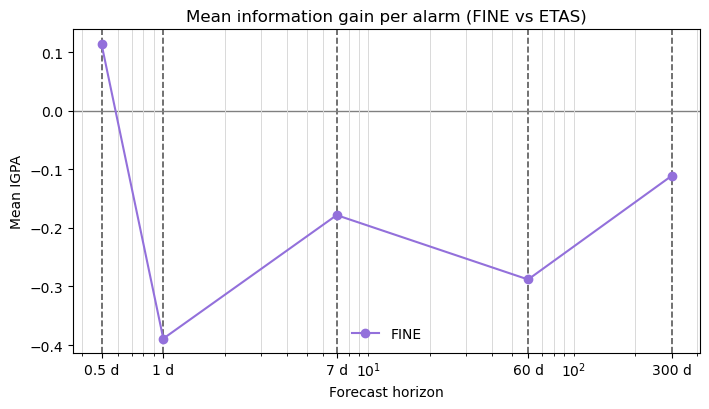

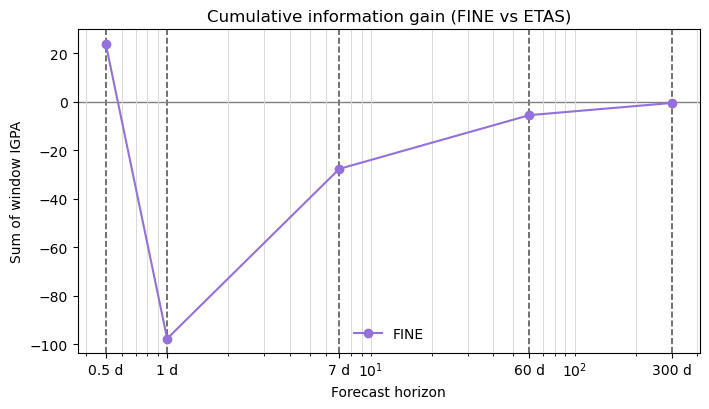

,horizon_days,information_gain,ig_lower,ig_upper,t_statistic,t_critical,n_observed,n_forecast_FINE,n_forecast_etas,significant
0,0.5,1.688224,1.640889,1.735560,70.009701,1.962975,1088,1016.274209,2194.064765,True
1,1.0,-1.973570,-2.043800,-1.903340,-55.162524,1.962975,1088,3541.141915,825.343113,True
2,7.0,-0.182837,-0.217362,-0.148313,-10.395623,1.962975,1088,974.806271,909.672914,True
3,60.0,-0.348711,-0.390817,-0.306605,-16.256871,1.962975,1088,1151.422408,929.083122,True
4,300.0,-0.075968,-0.134072,-0.017863,-2.566435,1.962975,1088,1072.704722,1067.194505,True


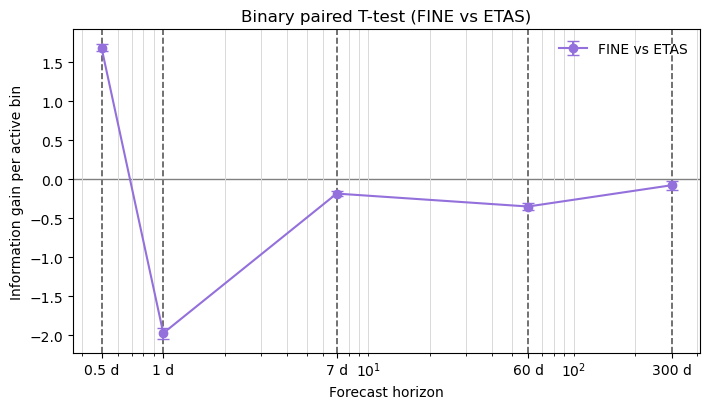

In [3]:
import etas.csep_utils as csep_utils
from csep.core import binomial_evaluations

# PyCSEP binary_paired_t_test / matrix_binary_t_test use ``np`` without importing it.
if not hasattr(binomial_evaluations, "np"):
    binomial_evaluations.np = np

comparison_metric_specs = [
    {
        "metric": "mean_igpa",
        "title": "Mean information gain per alarm (FINE vs ETAS)",
        "ylabel": "Mean IGPA",
        "methods_to_plot": ["FINE"],
        "hline": 0.0,
    },
    {
        "metric": "cumulative_igpa",
        "title": "Cumulative information gain (FINE vs ETAS)",
        "ylabel": "Sum of window IGPA",
        "methods_to_plot": ["FINE"],
        "hline": 0.0,
    },
]

for spec in comparison_metric_specs:
    metric = spec["metric"]
    if metric not in plot_summary.columns or plot_summary[metric].isna().all():
        display(Markdown(f"*Skipped `{metric}`: not present in the loaded comparison cache.*"))
        continue
    plot_metric_vs_horizon(
        plot_summary,
        metric,
        title=spec["title"],
        ylabel=spec["ylabel"],
        ylim=spec.get("ylim"),
        methods_to_plot=spec.get("methods_to_plot"),
        hline=spec.get("hline"),
    )


def build_binary_paired_t_table() -> pd.DataFrame:
    """Horizon-level PyCSEP binary paired T-test of FINE against ETAS."""
    rows: list[dict] = []
    for experiment in EXPERIMENTS:
        comparison = horizon_comparison.load_comparison(experiment["output_root"])
        for days in experiment["horizon_days"]:
            days = float(days)
            try:
                store = comparison.analysis(days)
            except FileNotFoundError:
                continue
            if "FINE" not in store.methods or "etas" not in store.methods:
                continue
            rates = store.mean_rate_grid()
            if "FINE" not in rates or "etas" not in rates:
                display(Markdown(
                    f"*Skipped binary paired T-test at {days:g} d: missing mean rate grids.*"
                ))
                continue
            windows = store.windows()
            if windows.empty:
                continue
            region, study_poly, fit = store.forecast_region()
            start = windows["forecast_start"].min().to_pydatetime()
            end = windows["forecast_end"].max().to_pydatetime()
            forecast_fine = csep_utils.gridded_forecast_from_rates(
                rates["FINE"], region, start, end, METHOD_LABELS.get("FINE", "FINE"),
            )
            forecast_etas = csep_utils.gridded_forecast_from_rates(
                rates["etas"], region, start, end, METHOD_LABELS.get("etas", "ETAS"),
            )
            observed = store.observed_frame().copy()
            if "time" not in observed.columns and "time_days" in observed.columns:
                observed["time"] = (
                    pd.Timestamp("1970-01-01")
                    + pd.to_timedelta(observed["time_days"], unit="D")
                )
            observed = csep_utils.filter_to_csep_region(
                observed,
                region=region,
                m_ref=float(fit["m_ref"]),
                study_poly=study_poly,
            )
            observed_catalog = csep_utils.dataframe_to_csep_catalog(
                observed, catalog_id=int(round(10 * days)), region=region,
            )
            if observed_catalog.event_count < 2:
                display(Markdown(
                    f"*Skipped binary paired T-test at {days:g} d: "
                    f"only {observed_catalog.event_count} observed events.*"
                ))
                continue
            result = binomial_evaluations.binary_paired_t_test(
                forecast_fine, forecast_etas, observed_catalog,
            )
            ig_lower, ig_upper = result.test_distribution
            t_statistic, t_critical = result.quantile
            rows.append({
                "horizon_days": days,
                "information_gain": float(result.observed_statistic),
                "ig_lower": float(ig_lower),
                "ig_upper": float(ig_upper),
                "t_statistic": float(t_statistic),
                "t_critical": float(t_critical),
                "n_observed": int(observed_catalog.event_count),
                "n_forecast_FINE": float(forecast_fine.event_count),
                "n_forecast_etas": float(forecast_etas.event_count),
                "significant": bool(ig_lower > 0.0 or ig_upper < 0.0),
            })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("horizon_days").reset_index(drop=True)


def plot_binary_paired_t_vs_horizon(
    table: pd.DataFrame,
    *,
    title: str = "Binary paired T-test (FINE vs ETAS)",
) -> None:
    """Information gain from a binary T-test table with 95% interval whiskers."""
    if table.empty:
        display(Markdown(f"*Skipped {title}: no analysis caches loaded.*"))
        return
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    _style_horizon_axis(ax)
    ax.axhline(0.0, color="0.5", linewidth=1.0, zorder=1)
    x = table["horizon_days"].to_numpy(dtype=float)
    ig = table["information_gain"].to_numpy(dtype=float)
    yerr = np.vstack([
        ig - table["ig_lower"].to_numpy(dtype=float),
        table["ig_upper"].to_numpy(dtype=float) - ig,
    ])
    color = METHOD_COLORS.get("FINE", "mediumpurple")
    ax.errorbar(
        x, ig, yerr=yerr,
        fmt="o-", color=color, ecolor=color, elinewidth=1.4, capsize=4,
        label="FINE vs ETAS", zorder=2,
    )
    ax.set_ylabel("Information gain per active bin")
    ax.set_title(title + partial_note)
    ax.legend(frameon=False)
    fig.tight_layout()
    show_fig(fig)


binary_paired_t = build_binary_paired_t_table()
display(binary_paired_t)
plot_binary_paired_t_vs_horizon(binary_paired_t)


### Direct PyCSEP `matrix_binary_t_test`

Call `csep.core.binomial_evaluations.matrix_binary_t_test` on each horizon's pooled FINE / ETAS grids. Results are kept in `matrix_binary_t_results` (list of dicts, one per horizon) for exploration.


In [ ]:
# Inputs match binary_paired_t_test, then call PyCSEP matrix_binary_t_test directly.
matrix_binary_t_results = []
for experiment in EXPERIMENTS:
    comparison = horizon_comparison.load_comparison(experiment["output_root"])
    for days in experiment["horizon_days"]:
        days = float(days)
        try:
            store = comparison.analysis(days)
        except FileNotFoundError:
            continue
        rates = store.mean_rate_grid()
        if "FINE" not in rates or "etas" not in rates:
            continue
        windows = store.windows()
        if windows.empty:
            continue
        region, study_poly, fit = store.forecast_region()
        start = windows["forecast_start"].min().to_pydatetime()
        end = windows["forecast_end"].max().to_pydatetime()
        forecast_fine = csep_utils.gridded_forecast_from_rates(
            rates["FINE"], region, start, end, "FINE",
        )
        forecast_etas = csep_utils.gridded_forecast_from_rates(
            rates["etas"], region, start, end, "ETAS",
        )
        observed = store.observed_frame().copy()
        if "time" not in observed.columns and "time_days" in observed.columns:
            observed["time"] = (
                pd.Timestamp("1970-01-01")
                + pd.to_timedelta(observed["time_days"], unit="D")
            )
        observed = csep_utils.filter_to_csep_region(
            observed, region=region, m_ref=float(fit["m_ref"]), study_poly=study_poly,
        )
        catalog = csep_utils.dataframe_to_csep_catalog(
            observed, catalog_id=int(round(10 * days)), region=region,
        )
        # Same indexing as binary_paired_t_test (active space–magnitude bins).
        active = np.unique(np.nonzero(catalog.spatial_magnitude_counts().ravel())[0])
        target_rates_fine = forecast_fine.data.ravel()[active]
        target_rates_etas = forecast_etas.data.ravel()[active]
        n_f_fine = float(np.sum(forecast_fine.data))
        n_f_etas = float(np.sum(forecast_etas.data))
        out = binomial_evaluations.matrix_binary_t_test(
            target_rates_fine,
            target_rates_etas,
            catalog.event_count,
            n_f_fine,
            n_f_etas,
            catalog,
        )
        matrix_binary_t_results.append({
            "horizon_days": days,
            "n_active_bins": int(active.size),
            "n_observed": int(catalog.event_count),
            "n_f_FINE": n_f_fine,
            "n_f_etas": n_f_etas,
            "result": out,
        })

display(matrix_binary_t_results)
if matrix_binary_t_results:
    display(matrix_binary_t_results[0]["result"])


In [ ]:
display(cumulative_number)
display(plot_summary.sort_values(["horizon_days", "method"]).reset_index(drop=True))
display(binary_paired_t)
display(matrix_binary_t_results)
